In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import pickle


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [6]:
df.select_dtypes(include=['object']).describe()# categorical features

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,45000,45000,45000,45000,45000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,24841,13399,23443,9153,22858


In [7]:
df.select_dtypes(exclude=['object']).describe()# numerical features

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [8]:
feature_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]# features with missing values
for feature in feature_with_na:
    print(feature, np.round(df[feature].isnull().mean(),4), '% missing values')

In [9]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [11]:
df.shape

(45000, 14)

In [12]:
df.size

630000

In [13]:
numberical_features = [feature for feature in df.columns if df[feature].dtype != 'O']# numerical features
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']# categorical features
continue_features = [feature for feature in numberical_features if len(df[feature].unique())>25]# continuous features
discrete_features = [feature for feature in numberical_features if feature not in continue_features]# discrete features
print('Number of numerical features:', len(numberical_features))
print('Number of categorical features:', len(categorical_features))
print('Number of continuous features:', len(continue_features))
print('Number of discrete features:', len(discrete_features))

print('Numerical features:', numberical_features)
print('Categorical features:', categorical_features)
print('Continuous features:', continue_features)
print('Discrete features:', discrete_features)



Number of numerical features: 14
Number of categorical features: 0
Number of continuous features: 8
Number of discrete features: 6
Numerical features: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Categorical features: []
Continuous features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Discrete features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file', 'loan_status']


In [14]:
df["person_age"].value_counts()  

person_age
23.0     5254
24.0     5138
25.0     4507
22.0     4236
26.0     3659
27.0     3095
28.0     2728
29.0     2455
30.0     2021
31.0     1645
32.0     1403
21.0     1289
33.0     1240
34.0      980
35.0      847
36.0      740
37.0      666
38.0      503
39.0      389
40.0      349
41.0      303
42.0      247
43.0      215
44.0      177
45.0      135
46.0      114
47.0      112
48.0       93
49.0       59
50.0       56
51.0       46
52.0       42
53.0       35
54.0       24
55.0       24
58.0       20
56.0       20
20.0       17
57.0       17
60.0       16
61.0       12
66.0       11
65.0       10
62.0        7
64.0        7
70.0        7
59.0        6
69.0        5
144.0       3
73.0        3
63.0        3
123.0       2
78.0        1
94.0        1
80.0        1
84.0        1
76.0        1
67.0        1
116.0       1
109.0       1
Name: count, dtype: int64

In [15]:
print("Number of people:", len(df["person_age"]))
print("Sorted ages:")
print(df["person_age"].sort_values(ascending=True)) 


Number of people: 45000
Sorted ages:
1313      20.0
12943     20.0
17196     20.0
11889     20.0
11902     20.0
         ...  
747      123.0
575      123.0
183      144.0
32297    144.0
81       144.0
Name: person_age, Length: 45000, dtype: float64


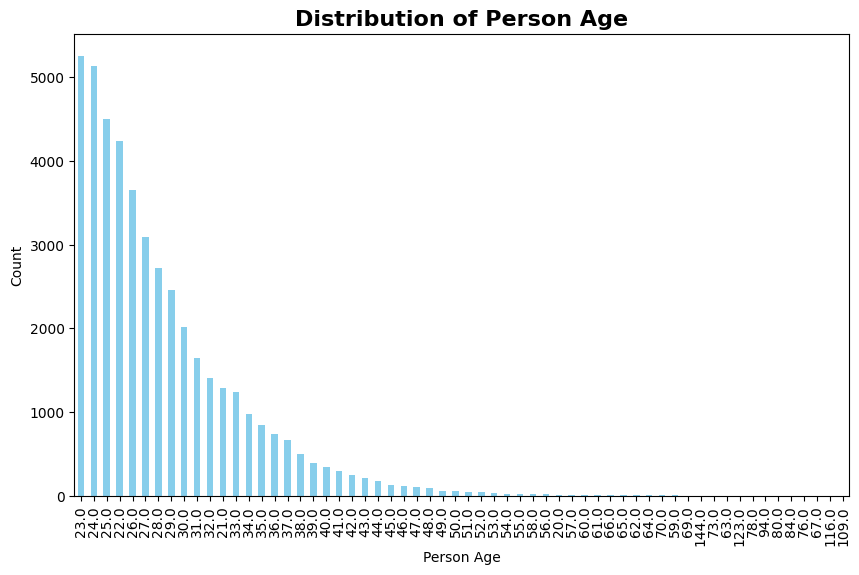

In [16]:
df["person_age"].value_counts().plot(kind='bar', figsize=(10,6), color='skyblue')
plt.xlabel('Person Age')
plt.ylabel('Count')
plt.title('Distribution of Person Age', fontsize=16, fontweight='bold')
plt.show()

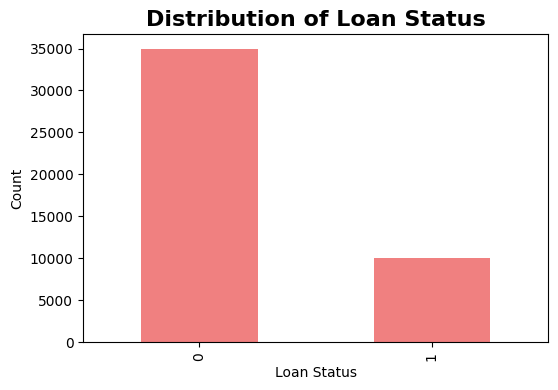

In [17]:
df["loan_status"].value_counts().plot(kind='bar', figsize=(6,4), color='lightcoral')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.show()  

In [18]:
X = df.drop('loan_status', axis=1) # features
y = df['loan_status']# target variable

In [19]:
X

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No


In [20]:
# Create Column Transformer with 3 types of transformers
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [21]:
le = LabelEncoder()
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = le.fit_transform(X[col])
X.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36000, 13), (9000, 13), (36000,), (9000,))

In [23]:
pd.DataFrame(X_train)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
6048,24.0,1,4,58914.0,2,2,4400.0,5,5.99,0.07,4.0,656,1
3346,23.0,0,3,45873.0,2,3,11000.0,5,11.01,0.24,2.0,634,1
17998,29.0,0,4,240947.0,7,0,10000.0,5,12.69,0.04,9.0,638,1
24988,30.0,0,1,96316.0,10,0,6000.0,3,13.49,0.06,8.0,682,0
23231,29.0,1,1,73033.0,7,0,8000.0,4,10.51,0.11,8.0,644,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3245,23.0,1,1,89921.0,3,3,3500.0,1,12.87,0.04,3.0,634,1
17803,25.0,0,0,35911.0,2,3,3000.0,1,6.62,0.08,4.0,573,0
28842,30.0,1,1,72786.0,9,2,20000.0,1,6.17,0.27,9.0,477,1
21553,30.0,1,0,39629.0,8,3,6000.0,3,12.99,0.15,9.0,689,0


In [24]:
pd.DataFrame(X_test)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
10750,25.0,0,1,84973.0,2,0,14000.0,5,5.42,0.16,3.0,634,0
17512,24.0,1,1,87280.0,2,2,16000.0,1,12.42,0.18,2.0,610,1
17070,22.0,0,0,70178.0,0,2,6500.0,5,7.49,0.09,3.0,668,1
35943,27.0,1,1,176144.0,1,0,2500.0,3,8.49,0.01,6.0,591,1
15749,26.0,0,1,181548.0,3,0,10000.0,0,15.99,0.06,3.0,643,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10107,23.0,1,0,65677.0,1,3,9500.0,3,14.65,0.14,2.0,605,1
34212,25.0,0,4,68132.0,1,0,5000.0,4,6.24,0.07,4.0,579,1
40679,24.0,0,1,52801.0,5,3,5000.0,1,12.47,0.09,4.0,684,1
22371,33.0,1,4,67209.0,7,0,3500.0,2,10.65,0.05,5.0,650,1


In [25]:
pd.DataFrame(y_train)

,loan_status
6048,0
3346,0
17998,0
24988,0
23231,0
...,...
3245,0
17803,1
28842,0
21553,0


In [26]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "KN": KNeighborsClassifier(),
    "Support Vector": SVC()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc
    Classification_report = classification_report(y_test, y_test_pred)


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    print("-Classification_report:", Classification_report)

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8327
- F1 score: 0.8159
- Precision: 0.7086
- Recall: 0.4199
- Roc Auc Score: 0.6853
----------------------------------
Model performance for Test set
- Accuracy: 0.8330
- F1 score: 0.8152
- Precision: 0.7163
- Recall: 0.4115
- Roc Auc Score: 0.6825
-Classification_report:               precision    recall  f1-score   support

           0       0.85      0.95      0.90      7000
           1       0.72      0.41      0.52      2000

    accuracy                           0.83      9000
   macro avg       0.78      0.68      0.71      9000
weighted avg       0.82      0.83      0.82      9000



Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9007
- F1 score: 0.9005
- Precision: 0.7787
- Recall: 0.7725
- Roc Auc Score: 0.8549
-Classificatio

In [27]:
## hyperparameter tuning
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "sqrt", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'sqrt', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [28]:

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2],
}

In [29]:
#model list for hyperparameter tunning
randomcv_models = ["RF", RandomForestClassifier(), rf_params]

randomcv_models

['RF',
 RandomForestClassifier(),
 {'max_depth': [5, 8, 15, None, 10],
  'max_features': [5, 7, 'sqrt', 8],
  'min_samples_split': [2, 8, 15, 20],
  'n_estimators': [100, 200, 500, 1000]}]

In [30]:
randomcv_models = [
    ("RandomForest", RandomForestClassifier(), rf_params),
    ("XGBoost", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False
    ), xgb_params),
]

In [31]:
randomcv_models = [
    ("RandomForest", RandomForestClassifier(), rf_params),
    ("XGBoost", XGBClassifier(), xgb_params),
]

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
        random_state=42
    )
    random.fit(X_train, y_train)
    print(f"{name} best score: {random.best_score_}")


Fitting 3 folds for each of 100 candidates, totalling 300 fits


[CV] END max_depth=None, max_features=sqrt, min_samples_split=8, n_estimators=500; total time=  50.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_split=8, n_estimators=1000; total time= 1.4min
[CV] END max_depth=15, max_features=sqrt, min_samples_split=8, n_estimators=1000; total time= 1.4min
[CV] END max_depth=15, max_features=sqrt, min_samples_split=8, n_estimators=1000; total time= 1.5min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=8, n_estimators=500; total time=  40.0s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=  11.1s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=   7.9s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=   8.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=8, n_estimators=500; total time=  34.8s
[CV] END max_depth=5, max_features=5, min_samples_split=15, n_estimators=200; total time=  11.3s
[CV

In [32]:

models = {
    "Random_Forest": RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        max_features=7,
        min_samples_split=2,
        random_state=42
    ),

    "Extreme Gradient Boosting": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')


Random_Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9320
- F1 score: 0.9305
- Precision: 0.8916
- Recall: 0.7900
- Roc Auc Score: 0.8813


Extreme Gradient Boosting
Model performance for Training set
- Accuracy: 0.9698
- F1 score: 0.9694
- Precision: 0.9653
- Recall: 0.8964
- Roc Auc Score: 0.9436
----------------------------------
Model performance for Test set
- Accuracy: 0.9378
- F1 score: 0.9366
- Precision: 0.8978
- Recall: 0.8125
- Roc Auc Score: 0.8930




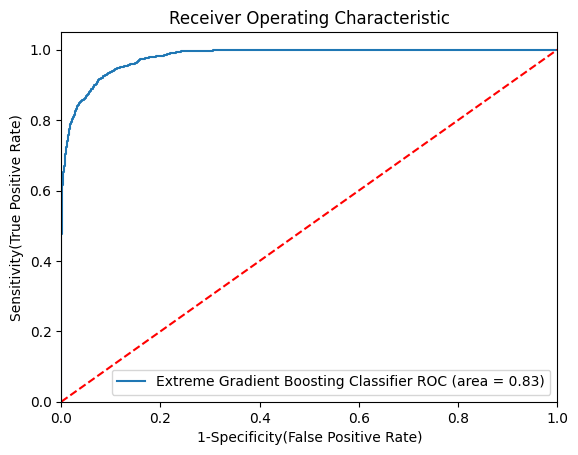

In [33]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Extreme Gradient Boosting Classifier',
    'model':XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),
    'auc':  0.8325
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 

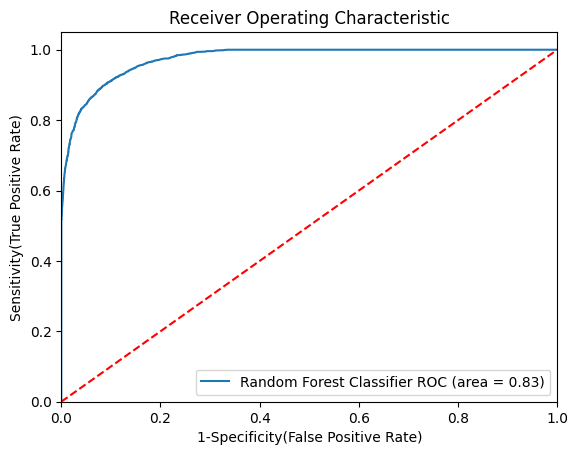

In [34]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model': RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=7,max_depth=None),
    'auc':  0.8325
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 

In [35]:
import os
os.makedirs("models", exist_ok=True)


In [36]:
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities (IMPORTANT for ROC-AUC)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_rocauc = roc_auc_score(y_train, y_train_proba)

    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_rocauc = roc_auc_score(y_test, y_test_proba)

    # Print results
    print("Model performance for Training set")
    print(f"- Accuracy: {train_accuracy:.4f}")
    print(f"- F1 score: {train_f1:.4f}")
    print(f"- Precision: {train_precision:.4f}")
    print(f"- Recall: {train_recall:.4f}")
    print(f"- ROC-AUC: {train_rocauc:.4f}")

    print("----------------------------------")

    print("Model performance for Test set")
    print(f"- Accuracy: {test_accuracy:.4f}")
    print(f"- F1 score: {test_f1:.4f}")
    print(f"- Precision: {test_precision:.4f}")
    print(f"- Recall: {test_recall:.4f}")
    print(f"- ROC-AUC: {test_rocauc:.4f}")

    print("=" * 35, "\n")

    # ✅ Pickle model
    model_path = f"models/{model_name.replace(' ', '_').lower()}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Saved model to {model_path}\n")


Training Random_Forest...
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC-AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9320
- F1 score: 0.9305
- Precision: 0.8916
- Recall: 0.7900
- ROC-AUC: 0.9748

Saved model to models/random_forest.pkl

Training Extreme Gradient Boosting...
Model performance for Training set
- Accuracy: 0.9698
- F1 score: 0.9694
- Precision: 0.9653
- Recall: 0.8964
- ROC-AUC: 0.9960
----------------------------------
Model performance for Test set
- Accuracy: 0.9378
- F1 score: 0.9366
- Precision: 0.8978
- Recall: 0.8125
- ROC-AUC: 0.9801

Saved model to models/extreme_gradient_boosting.pkl



In [37]:
from sklearn.preprocessing import StandardScaler
import pickle
import os

os.makedirs("models", exist_ok=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [38]:
os.makedirs("models", exist_ok=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


scaler_path = "models/scaler.pkl"

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print(f"Scaler saved to {scaler_path}")

Scaler saved to models/scaler.pkl


In [39]:
import pickle

with open("models/extreme_gradient_boosting.pkl", "rb") as f:
    xgb_model = pickle.load(f)


In [40]:
with open("models/random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

[![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python&logoColor=white)](https://www.python.org/)
[![Flask](https://img.shields.io/badge/Flask-Web%20Framework-black?logo=flask&logoColor=white)](https://flask.palletsprojects.com/)
[![XGBoost](https://img.shields.io/badge/XGBoost-ML%20Model-orange)](https://xgboost.readthedocs.io/)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-ML-yellow?logo=scikitlearn&logoColor=white)](https://scikit-learn.org/)
[![License: MIT](https://img.shields.io/badge/License-MIT-green)](https://opensource.org/licenses/MIT)
